In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Set population size
N = 1000
# Set number of simulation rounds
t_max = 5000

# Initialise z
z = np.ones(N)

# Storage vectors
z_bar = np.empty(t_max)
z_delta_bar = np.empty(t_max)

# Parameters for Gumbel distribution
sigma = 1
alpha = 7

for r in range(t_max):
    # Draw from Gumbel(mu, beta) where beta = sigma
    z_new = np.random.gumbel(loc=z.max() - alpha, scale=sigma, size=N)

    # Record average skill level
    z_bar[r] = z_new.mean()

    # Record average change
    z_delta_bar[r] = (z_new - z).mean()

    # Update z
    z = z_new


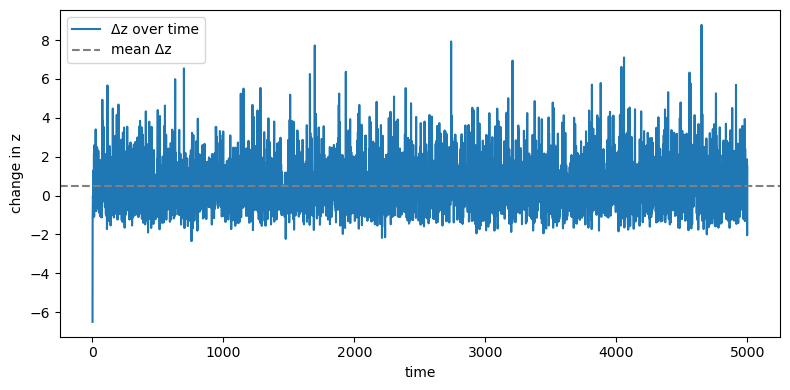

In [3]:
# Build tidy-style dataframe
z_delta_bar_val = pd.DataFrame({
    "x": np.arange(1, len(z_delta_bar) + 1),
    "y": z_delta_bar
})

# Plot
plt.figure(figsize=(8, 4))
plt.plot(z_delta_bar_val["x"], z_delta_bar_val["y"], label="Δz over time")

# Horizontal mean line
plt.axhline(
    y=z_delta_bar_val["y"].mean(),
    color="grey",
    linestyle="--",
    label="mean Δz"
)

plt.xlabel("time")
plt.ylabel("change in z")
plt.legend()
plt.tight_layout()
plt.show()

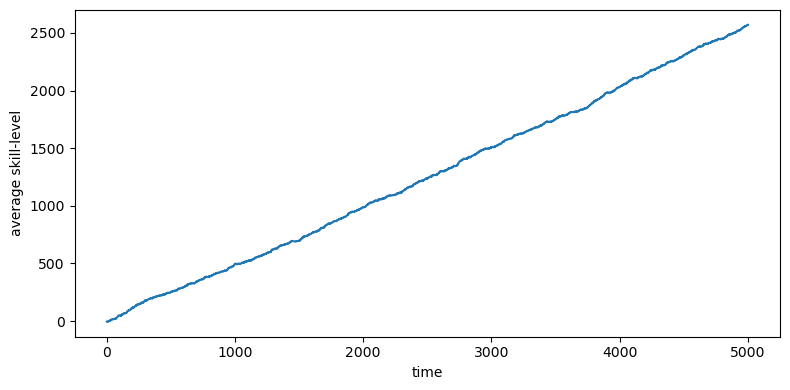

In [4]:
# Build tidy-style dataframe
z_bar_val = pd.DataFrame({
    "x": np.arange(1, len(z_bar) + 1),
    "y": z_bar
})

# Plot
plt.figure(figsize=(8, 4))
plt.plot(z_bar_val["x"], z_bar_val["y"], label="average skill-level")

plt.xlabel("time")
plt.ylabel("average skill-level")
plt.tight_layout()
plt.show()

In [5]:
def demography_model(T_MAX, N, ALPHA, SIGMA, R_MAX):
    results = []

    for _ in range(R_MAX):
        z = np.ones(N)
        z_delta_bar = np.empty(T_MAX)

        for t in range(T_MAX):
            z_new = np.random.gumbel(
                loc=z.max() - ALPHA,
                scale=SIGMA,
                size=N
            )
            z_delta_bar[t] = (z_new - z).mean()
            z = z_new

        results.append(z_delta_bar.mean())

    return np.mean(results)


In [6]:
sizes = np.concatenate(([2], np.arange(100, 6101, 500)))

simple_skill = [
    demography_model(T_MAX=200, N=N, ALPHA=7, SIGMA=1, R_MAX=20)
    for N in sizes
]

complex_skill = [
    demography_model(T_MAX=200, N=N, ALPHA=9, SIGMA=1, R_MAX=20)
    for N in sizes
]

z_delta_bar = np.ravel(np.column_stack([simple_skill, complex_skill]))

data = pd.DataFrame({
    "N": np.repeat(sizes, 2),
    "z_delta_bar": z_delta_bar,
    "skill": np.tile(["simple", "complex"], reps=len(sizes))
})

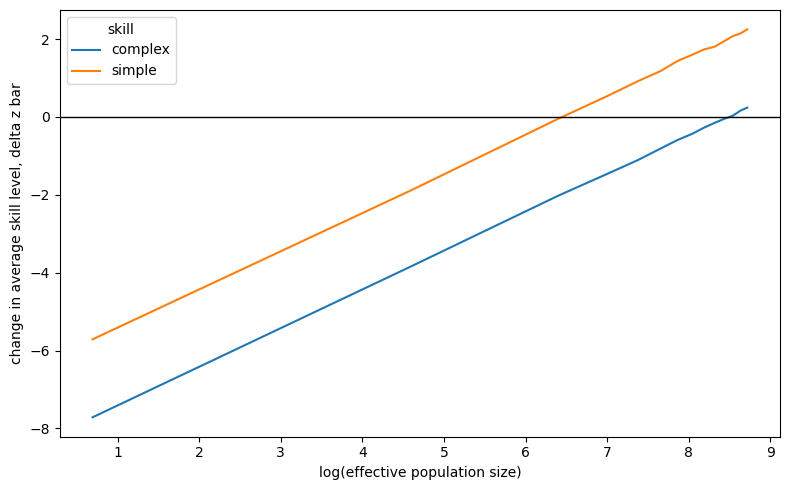

In [7]:
plt.figure(figsize=(8, 5))

# Plot each skill type separately, like ggplot's color = skill
for skill_type, df_sub in data.groupby("skill"):
    plt.plot(np.log(df_sub["N"]), df_sub["z_delta_bar"], label=skill_type)

# Horizontal line at y = 0
plt.axhline(y=0, color="black", linewidth=1)

plt.xlabel("log(effective population size)")
plt.ylabel("change in average skill level, delta z bar")
plt.legend(title="skill")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression

# Subset to simple skill only
df_simple = data[data["skill"] == "simple"]

# Prepare X and y
X = np.log(df_simple["N"]).values.reshape(-1, 1)
y = df_simple["z_delta_bar"].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Coefficients
intercept = model.intercept_
slope = model.coef_[0]

print("intercept:", intercept)
print("slope:", slope)

intercept: -6.411281863293321
slope: 0.9928953774369332


In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np

# --- SIMPLE SKILL ---
df_simple = data[data["skill"] == "simple"]

X_simple = np.log(df_simple["N"]).values.reshape(-1, 1)
y_simple = df_simple["z_delta_bar"].values

model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)

b_simple = model_simple.intercept_
m_simple = model_simple.coef_[0]

N_star_simple = np.exp(-(b_simple / m_simple))


# --- COMPLEX SKILL ---
df_complex = data[data["skill"] == "complex"]

X_complex = np.log(df_complex["N"]).values.reshape(-1, 1)
y_complex = df_complex["z_delta_bar"].values

model_complex = LinearRegression()
model_complex.fit(X_complex, y_complex)

b_complex = model_complex.intercept_
m_complex = model_complex.coef_[0]

N_star_complex = np.exp(-(b_complex / m_complex))


print("N* (simple): ", N_star_simple)
print("N* (complex):", N_star_complex)


N* (simple):  637.247124174148
N* (complex): 4793.395592105559


In [10]:
sizes = np.arange(100, 6101, 500)
alphas = np.arange(4, 9.5, 0.5)   # stop is exclusive, so go to 9.5

simulations = pd.DataFrame(
    [(N, a) for N in sizes for a in alphas],
    columns=["N", "alpha"]
)

simulations.head()

,N,alpha
0,100,4.0
1,100,4.5
2,100,5.0
3,100,5.5
4,100,6.0


In [11]:
# Run simulation for each row of the grid
z_delta_bar = [
    demography_model(
        T_MAX=200,
        N=int(simulations.loc[i, "N"]),
        ALPHA=float(simulations.loc[i, "alpha"]),
        SIGMA=1,
        R_MAX=5
    )
    for i in range(len(simulations))
]

# Add results to the DataFrame
simulations["z_delta_bar"] = z_delta_bar

data = simulations

In [12]:
n_stars = []

for alpha in data["alpha"].unique():
    # Subset for this alpha
    subset = data[data["alpha"] == alpha]

    # Prepare X and y
    X = np.log(subset["N"]).values.reshape(-1, 1)
    y = subset["z_delta_bar"].values

    # Fit regression
    model = LinearRegression()
    model.fit(X, y)

    b = model.intercept_
    m = model.coef_[0]

    # Solve for N* = exp(-(b/m))
    n_star = np.exp(-(b / m))
    n_stars.append(n_star)

# Combine into a tidy DataFrame
results = pd.DataFrame({
    "alpha": data["alpha"].unique(),
    "n_star": n_stars
})

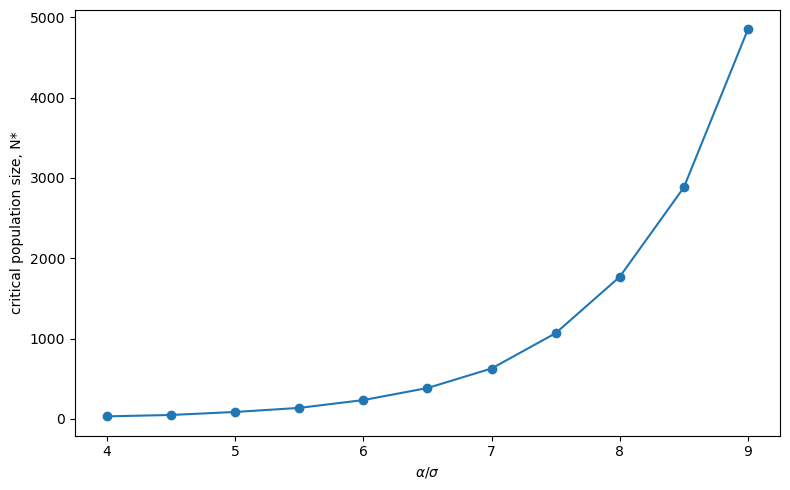

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(results["alpha"], results["n_star"], marker="o")

plt.xlabel(r"$\alpha / \sigma$")
plt.ylabel("critical population size, N*")

plt.tight_layout()
plt.show()